# Exploratory Data Analysis (EDA) - Dataset Penjualan UMKM
## Sistem Prediksi Penjualan Produk UMKM Menggunakan Random Forest

Notebook ini melakukan analisis mendalam terhadap dataset penjualan harian UMKM untuk memahami pola, tren, dan karakteristik data sebelum dilakukan preprocessing dan modeling.

## 1. Import Library & Konfigurasi

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from pathlib import Path

# Suppress warnings
warnings.filterwarnings('ignore')

# Set matplotlib style dan figsize default
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Semua library berhasil di-import dan konfigurasi selesai")

✅ Semua library berhasil di-import dan konfigurasi selesai


Failed to get a response. Please try again.

## 2. Load Dataset

In [4]:
def load_data(filepath):
    """
    Fungsi fleksibel untuk load dataset CSV atau Excel
    Deteksi otomatis berdasarkan ekstensi file
    """
    filepath = Path(filepath)
    
    if not filepath.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {filepath}")
    
    if filepath.suffix.lower() == '.csv':
        df = pd.read_csv(filepath)
        print(f"✅ File CSV berhasil di-load dari: {filepath}")
    elif filepath.suffix.lower() in ['.xlsx', '.xls']:
        df = pd.read_excel(filepath)
        print(f"✅ File Excel berhasil di-load dari: {filepath}")
    else:
        raise ValueError(f"Format file tidak didukung: {filepath.suffix}")
    
    return df

# Load dataset (path relatif dari root project)
# Sesuaikan nama file dengan dataset Anda
data_path = '../data/raw/dummy_dataset.csv'  # Ubah sesuai nama file Anda
df = load_data(data_path)

print(f"\n📊 Dimensi dataset: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\n📝 Kolom yang tersedia:")
print(df.columns.tolist())
print(f"\n🔍 Data 5 baris pertama:")
print(df.head())

✅ File CSV berhasil di-load dari: ..\data\raw\dummy_dataset.csv

📊 Dimensi dataset: 10 baris × 4 kolom

📝 Kolom yang tersedia:
['tanggal', 'produk', 'harga', 'jumlah']

🔍 Data 5 baris pertama:
      tanggal          produk  harga  jumlah
0  2024-01-01  Keripik Pisang  15000      20
1  2024-01-02      Bolu Kukus  12000      15
2  2024-01-03  Keripik Pisang  15000      25
3  2024-01-04      Bolu Kukus  12000      18
4  2024-01-05      Kopi Bubuk  20000      10


## 3. Informasi Umum Dataset

In [5]:
print("=" * 80)
print("📋 INFORMASI UMUM DATASET")
print("=" * 80)

print("\n📌 Info Tipe Data & Missing Values:")
df.info()

print("\n📊 Statistik Deskriptif - Kolom Numerik:")
print(df.describe().round(2))

print("\n📝 Statistik Deskriptif - Kolom Kategorikal:")
print(df.describe(include='object'))

print("\n🔢 Jumlah Unique Values per Kolom:")
unique_counts = pd.DataFrame({
    'Kolom': df.columns,
    'Unique': [df[col].nunique() for col in df.columns],
    'Persen_Unique': [(df[col].nunique() / len(df) * 100) for col in df.columns]
}).round(2)
print(unique_counts.to_string(index=False))

📋 INFORMASI UMUM DATASET

📌 Info Tipe Data & Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   tanggal  10 non-null     str  
 1   produk   10 non-null     str  
 2   harga    10 non-null     int64
 3   jumlah   10 non-null     int64
dtypes: int64(2), str(2)
memory usage: 452.0 bytes

📊 Statistik Deskriptif - Kolom Numerik:
          harga  jumlah
count     10.00   10.00
mean   15600.00   17.70
std     3306.56    5.06
min    12000.00   10.00
25%    12750.00   14.25
50%    15000.00   17.50
75%    18750.00   21.50
max    20000.00   25.00

📝 Statistik Deskriptif - Kolom Kategorikal:
           tanggal          produk
count           10              10
unique          10               3
top     2024-01-01  Keripik Pisang
freq             1               4

🔢 Jumlah Unique Values per Kolom:
  Kolom  Unique  Persen_Unique
tanggal      10          100.0
 produk 

## 4. Cek Missing Values

In [6]:
print("=" * 80)
print("🔍 ANALISIS MISSING VALUES")
print("=" * 80)

# Hitung missing values
missing_data = pd.DataFrame({
    'Kolom': df.columns,
    'Jumlah_Missing': df.isnull().sum(),
    'Persentase_Missing': (df.isnull().sum() / len(df) * 100)
}).sort_values('Jumlah_Missing', ascending=False)

missing_data = missing_data[missing_data['Jumlah_Missing'] > 0]

if len(missing_data) > 0:
    print("\n📊 Tabel Missing Values (diurutkan dari tertinggi):")
    print(missing_data.to_string(index=False))
    
    # Visualisasi heatmap
    plt.figure(figsize=(12, 4))
    sns.heatmap(df.isnull(), cbar=True, cmap='YlOrRd', yticklabels=False)
    plt.title('Heatmap Missing Values', fontsize=14, fontweight='bold')
    plt.xlabel('Kolom')
    plt.ylabel('Baris')
    plt.tight_layout()
    plt.show()
    
    print("\n⚠️ REKOMENDASI PENANGANAN MISSING VALUES:")
    for idx, row in missing_data.iterrows():
        kolom = row['Kolom']
        persen = row['Persentase_Missing']
        if persen > 50:
            print(f"  • {kolom}: Pertimbangkan untuk menghapus kolom (missing > 50%)")
        elif persen > 20:
            print(f"  • {kolom}: Gunakan imputation (missing ~{persen:.1f}%)")
        else:
            print(f"  • {kolom}: Bisa di-drop atau di-impute (missing ~{persen:.1f}%)")
else:
    print("\n✅ Tidak ada missing values dalam dataset!")

🔍 ANALISIS MISSING VALUES

✅ Tidak ada missing values dalam dataset!


## 5. Cek Duplikat

In [7]:
print("=" * 80)
print("🔄 ANALISIS DUPLIKAT")
print("=" * 80)

# Hitung duplikat
jumlah_duplikat = df.duplicated().sum()
persen_duplikat = (jumlah_duplikat / len(df) * 100)

print(f"\n📊 Total baris duplikat: {jumlah_duplikat} ({persen_duplikat:.2f}%)")

if jumlah_duplikat > 0:
    print(f"\n📝 Contoh baris duplikat (5 baris pertama):")
    duplikat_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(5)
    print(duplikat_rows)
    
    print("\n⚠️ REKOMENDASI:")
    if persen_duplikat > 5:
        print(f"  • Ada banyak duplikat ({persen_duplikat:.1f}%). Pertimbangkan untuk menghapus atau investigasi lebih lanjut.")
    else:
        print(f"  • Duplikat minimal ({persen_duplikat:.2f}%). Sebaiknya dihapus dengan df.drop_duplicates()")
else:
    print("\n✅ Tidak ada baris duplikat dalam dataset!")

🔄 ANALISIS DUPLIKAT

📊 Total baris duplikat: 0 (0.00%)

✅ Tidak ada baris duplikat dalam dataset!


## 6. Deteksi Outlier

📌 DETEKSI OUTLIER - METODE IQR

📊 Tabel Outlier per Kolom Numerik:
 Kolom  Lower_Bound  Upper_Bound  Jumlah_Outlier  Persen
 harga      3750.00     27750.00               0     0.0
jumlah         3.38        32.38               0     0.0


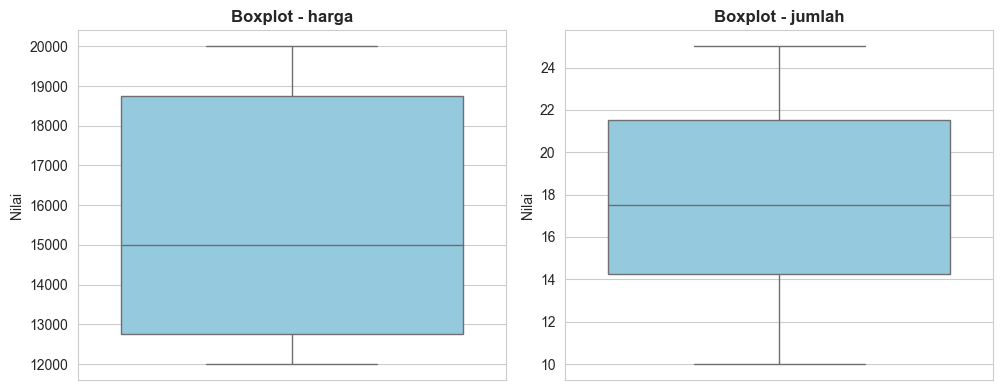


💡 INSIGHT:
  • Outlier terdeteksi dari nilai yang berada di luar batas IQR
  • Pertimbangkan untuk di-handle dengan capping atau removal


In [8]:
print("=" * 80)
print("📌 DETEKSI OUTLIER - METODE IQR")
print("=" * 80)

# Ambil hanya kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Deteksi outlier dengan IQR
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    persen_outlier = (outliers / len(df) * 100)
    
    outlier_summary.append({
        'Kolom': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Jumlah_Outlier': outliers,
        'Persen': persen_outlier
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df_display = outlier_df[['Kolom', 'Lower_Bound', 'Upper_Bound', 'Jumlah_Outlier', 'Persen']].round(2)

print("\n📊 Tabel Outlier per Kolom Numerik:")
print(outlier_df_display.to_string(index=False))

# Visualisasi boxplot grid
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[idx].set_ylabel('Nilai')

# Hapus subplot kosong
for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print("  • Outlier terdeteksi dari nilai yang berada di luar batas IQR")
print("  • Pertimbangkan untuk di-handle dengan capping atau removal")

## 7. Distribusi Target Variable

📈 ANALISIS DISTRIBUSI TARGET VARIABLE (JUMLAH_TERJUAL)


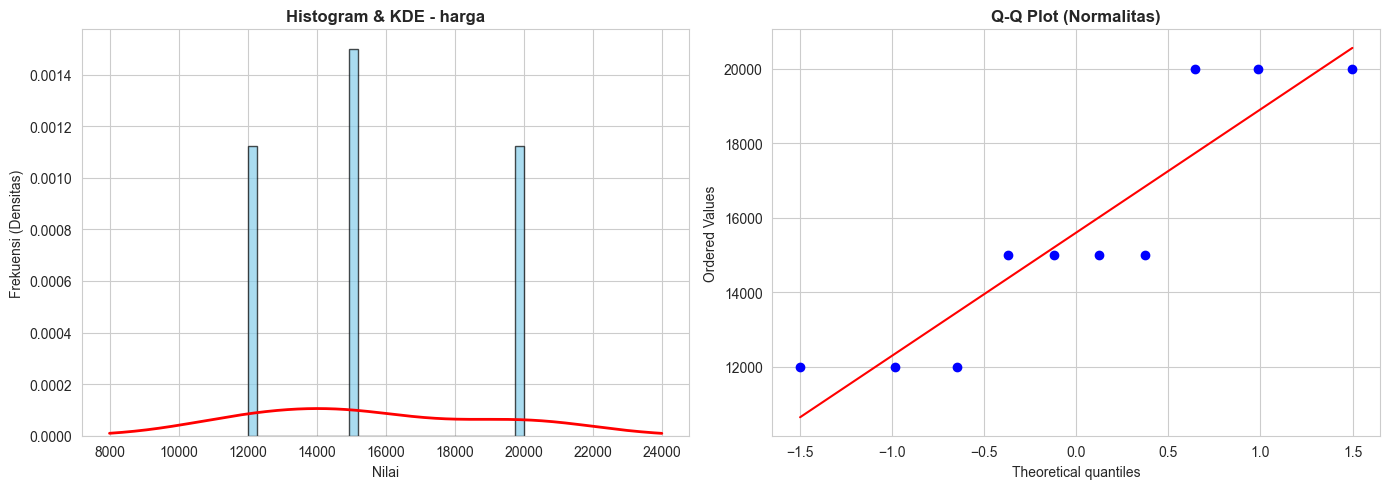


📊 STATISTIK DISTRIBUSI HARGA:
  • Mean: 15600.00
  • Median: 15000.00
  • Std Dev: 3306.56
  • Skewness: 0.44
  • Kurtosis: -1.37

💡 INTERPRETASI:
  • Distribusi relatif simetris (skewness ≈ 0)
  • Distribusi platikurtik (ekor ringan)


In [9]:
print("=" * 80)
print("📈 ANALISIS DISTRIBUSI TARGET VARIABLE (JUMLAH_TERJUAL)")
print("=" * 80)

# Ambil target variable (sesuaikan dengan nama kolom Anda)
target_col = 'jumlah_terjual' if 'jumlah_terjual' in df.columns else df.select_dtypes(include=[np.number]).columns[0]

# Plot histogram dengan KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
axes[0].hist(df[target_col], bins=30, edgecolor='black', alpha=0.7, color='skyblue', density=True)
df[target_col].plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].set_title(f'Histogram & KDE - {target_col}', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Nilai')
axes[0].set_ylabel('Frekuensi (Densitas)')

# Q-Q plot untuk cek normalitas
from scipy.stats import probplot
probplot(df[target_col].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normalitas)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Hitung statistik distribusi
skewness = df[target_col].skew()
kurtosis = df[target_col].kurtosis()
mean_val = df[target_col].mean()
median_val = df[target_col].median()
std_val = df[target_col].std()

print(f"\n📊 STATISTIK DISTRIBUSI {target_col.upper()}:")
print(f"  • Mean: {mean_val:.2f}")
print(f"  • Median: {median_val:.2f}")
print(f"  • Std Dev: {std_val:.2f}")
print(f"  • Skewness: {skewness:.2f}")
print(f"  • Kurtosis: {kurtosis:.2f}")

print(f"\n💡 INTERPRETASI:")
if abs(skewness) < 0.5:
    print(f"  • Distribusi relatif simetris (skewness ≈ 0)")
elif skewness > 0:
    print(f"  • Distribusi right-skewed (ekor ke kanan) - banyak nilai rendah")
else:
    print(f"  • Distribusi left-skewed (ekor ke kiri) - banyak nilai tinggi")

if abs(kurtosis) < 3:
    print(f"  • Distribusi platikurtik (ekor ringan)")
else:
    print(f"  • Distribusi leptokurtik (ekor berat) - banyak outlier")

## 8. Analisis Tren Penjualan (Time Series)

📅 ANALISIS TREN PENJUALAN (TIME SERIES)


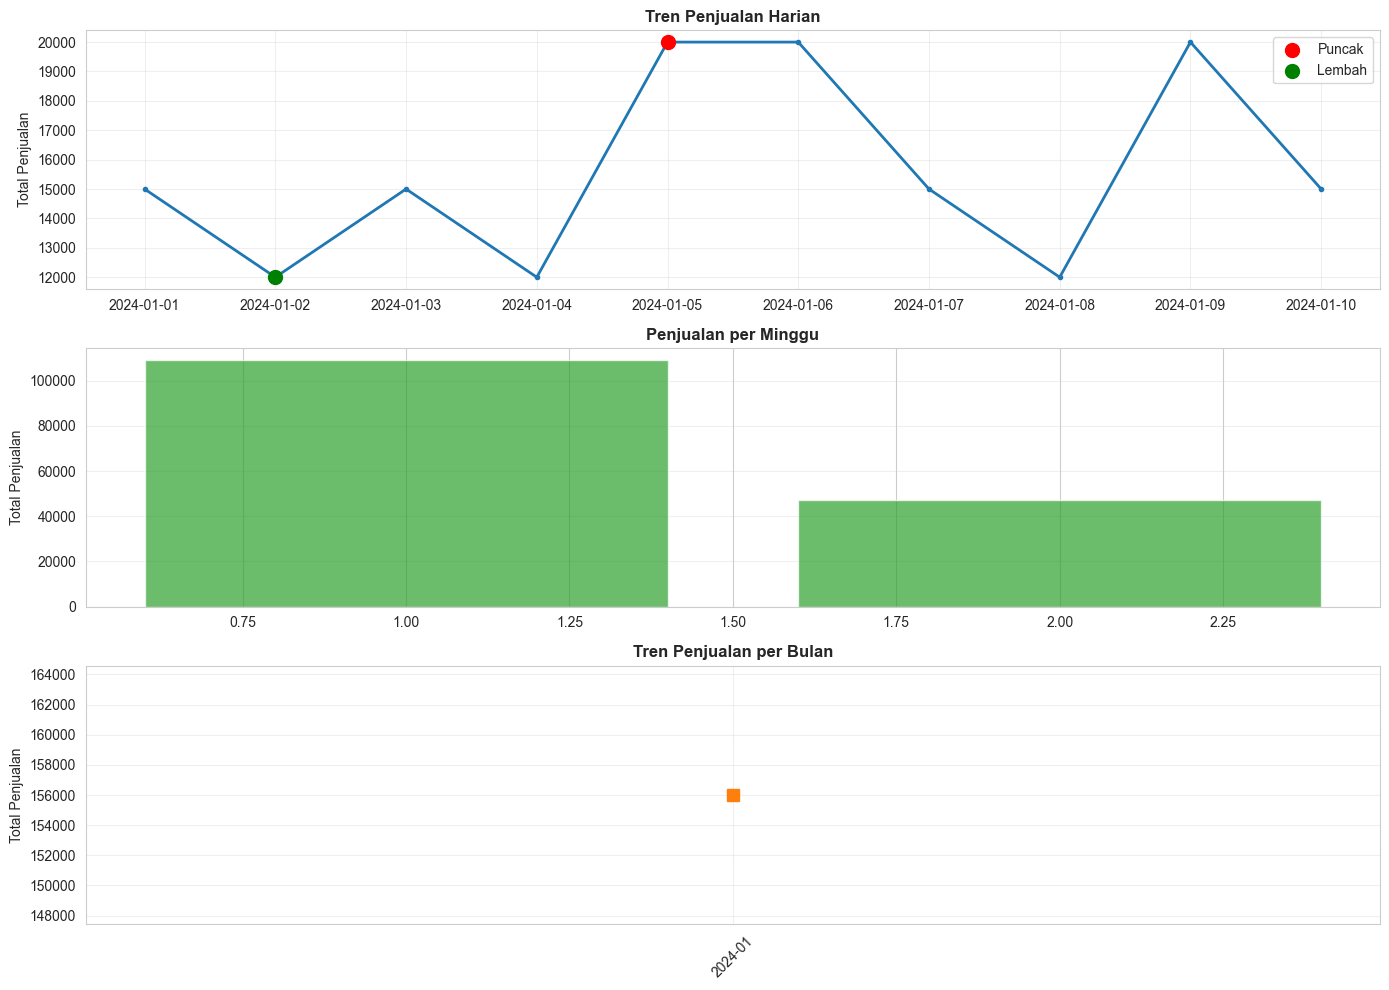


📊 INSIGHT TREN PENJUALAN:
  • Periode tertinggi (harian): 2024-01-05 dengan penjualan 20000 unit
  • Periode terendah (harian): 2024-01-02 dengan penjualan 12000 unit
  • Rata-rata penjualan harian: 15600.00 unit
  • Minggu dengan penjualan tertinggi: Minggu 1 (109000 unit)
  • Bulan dengan penjualan tertinggi: 2024-01 (156000 unit)


In [10]:
print("=" * 80)
print("📅 ANALISIS TREN PENJUALAN (TIME SERIES)")
print("=" * 80)

# Deteksi kolom tanggal
date_col = None
for col in df.columns:
    if 'tanggal' in col.lower() or 'date' in col.lower():
        date_col = col
        break

if date_col is None:
    print("⚠️  Kolom tanggal tidak ditemukan. Analisis time series dilewati.")
    print("   Pastikan ada kolom dengan nama yang mengandung 'tanggal' atau 'date'")
else:
    # Konversi ke datetime
    df[date_col] = pd.to_datetime(df[date_col])
    df_ts = df.sort_values(by=date_col)
    
    # Buat tren harian, mingguan, bulanan
    daily_sales = df_ts.groupby(df_ts[date_col].dt.date)[target_col].sum()
    weekly_sales = df_ts.groupby(df_ts[date_col].dt.isocalendar().week)[target_col].sum()
    monthly_sales = df_ts.groupby(df_ts[date_col].dt.to_period('M'))[target_col].sum()
    
    # Plot tren
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Tren Harian
    axes[0].plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', linewidth=2, markersize=3, color='#1f77b4')
    axes[0].set_title('Tren Penjualan Harian', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Total Penjualan')
    axes[0].grid(True, alpha=0.3)
    
    # Tandai puncak dan lembah
    max_day_idx = daily_sales.idxmax()
    min_day_idx = daily_sales.idxmin()
    axes[0].scatter([max_day_idx], [daily_sales[max_day_idx]], color='red', s=100, zorder=5, label='Puncak')
    axes[0].scatter([min_day_idx], [daily_sales[min_day_idx]], color='green', s=100, zorder=5, label='Lembah')
    axes[0].legend()
    
    # Tren Mingguan
    axes[1].bar(weekly_sales.index, weekly_sales.values, color='#2ca02c', alpha=0.7)
    axes[1].set_title('Penjualan per Minggu', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('Total Penjualan')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Tren Bulanan
    monthly_labels = [str(period) for period in monthly_sales.index]
    axes[2].plot(range(len(monthly_sales)), monthly_sales.values, marker='s', linestyle='-', linewidth=2, markersize=8, color='#ff7f0e')
    axes[2].set_title('Tren Penjualan per Bulan', fontweight='bold', fontsize=12)
    axes[2].set_ylabel('Total Penjualan')
    axes[2].set_xticks(range(len(monthly_sales)))
    axes[2].set_xticklabels(monthly_labels, rotation=45)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 INSIGHT TREN PENJUALAN:")
    print(f"  • Periode tertinggi (harian): {max_day_idx} dengan penjualan {daily_sales[max_day_idx]:.0f} unit")
    print(f"  • Periode terendah (harian): {min_day_idx} dengan penjualan {daily_sales[min_day_idx]:.0f} unit")
    print(f"  • Rata-rata penjualan harian: {daily_sales.mean():.2f} unit")
    print(f"  • Minggu dengan penjualan tertinggi: Minggu {weekly_sales.idxmax()} ({weekly_sales.max():.0f} unit)")
    print(f"  • Bulan dengan penjualan tertinggi: {monthly_sales.idxmax()} ({monthly_sales.max():.0f} unit)")

## 9. Analisis per Produk/Kategori

🏪 ANALISIS PER PRODUK & KATEGORI


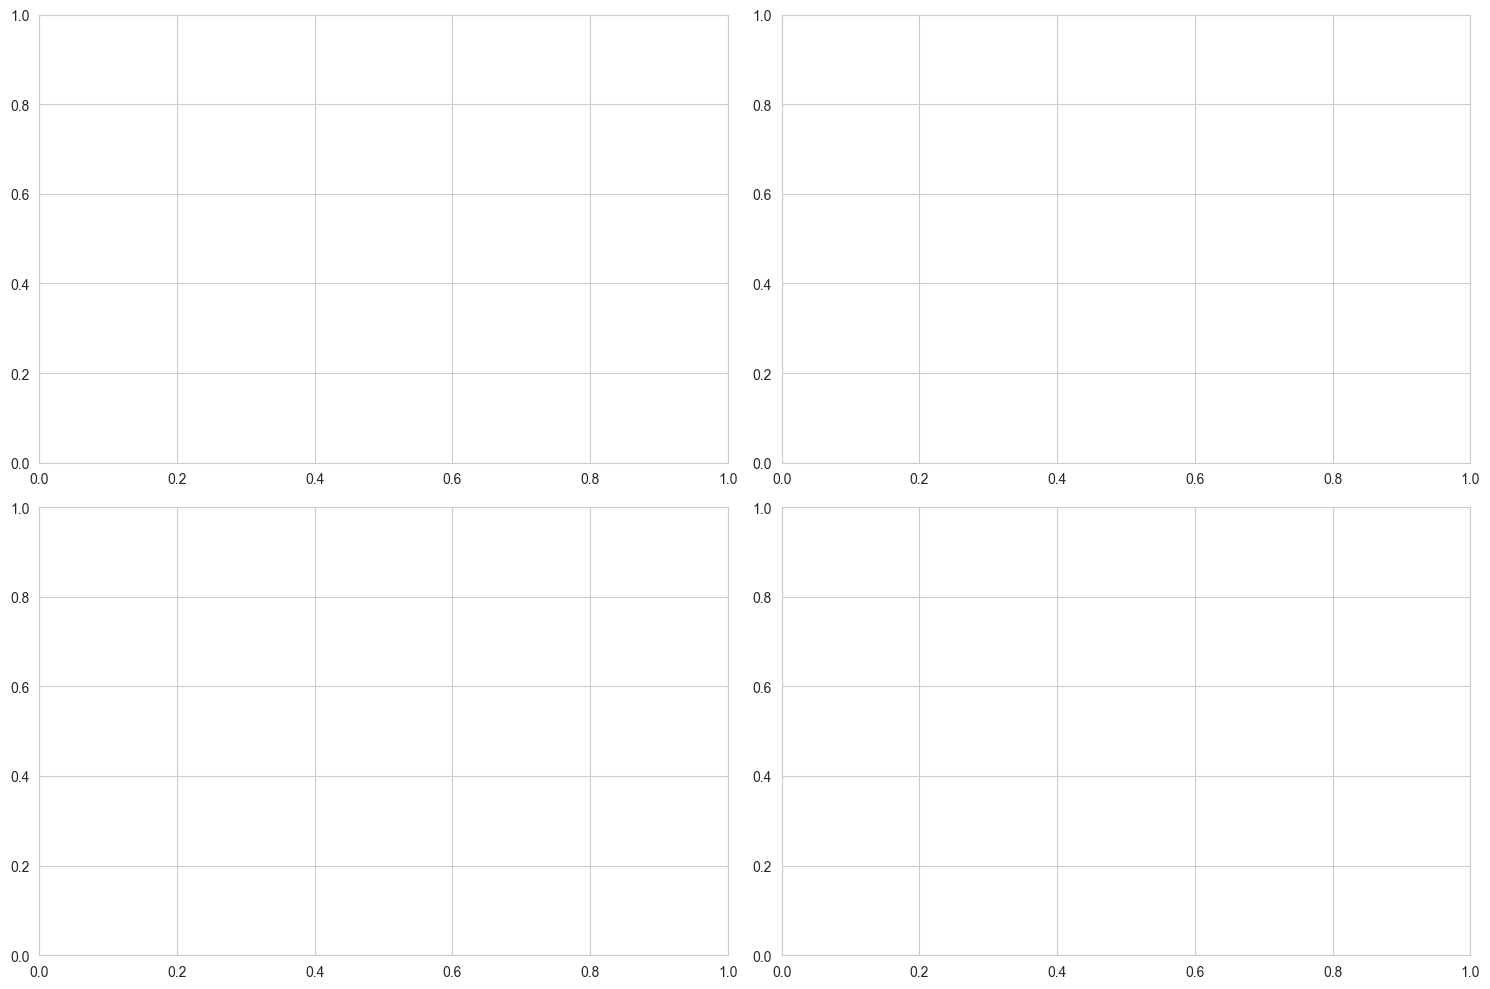

In [15]:
print("=" * 80)
print("🏪 ANALISIS PER PRODUK & KATEGORI")
print("=" * 80)

# Deteksi kolom produk dan kategori
product_col = None
category_col = None

for col in df.columns:
    if 'produk' in col.lower() and 'nama' in col.lower():
        product_col = col
    if 'kategori' in col.lower():
        category_col = col

if product_col is None:
    product_col = [col for col in df.columns if 'product' in col.lower()]
    product_col = product_col[0] if product_col else None

if category_col is None:
    category_col = [col for col in df.columns if 'category' in col.lower() or 'kategori' in col.lower()]
    category_col = category_col[0] if category_col else None

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 Produk Terlaris (by jumlah_terjual)
if product_col:
    top_products = df.groupby(product_col)[target_col].sum().nlargest(10)
    top_products.plot(kind='barh', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Top 10 Produk Terlaris (Total Penjualan)', fontweight='bold')
    axes[0, 0].set_xlabel('Total Penjualan')
    axes[0, 0].invert_yaxis()
    
    # Insight top produk
    print(f"\n📊 TOP 10 PRODUK TERLARIS:")
    for idx, (prod, qty) in enumerate(top_products.items(), 1):
        print(f"  {idx}. {prod}: {qty:.0f} unit")

# Penjualan per Kategori
if category_col:
    category_sales = df.groupby(category_col)[target_col].sum().sort_values(ascending=False)
    category_sales.plot(kind='bar', ax=axes[0, 1], color='lightgreen')
    axes[0, 1].set_title('Total Penjualan per Kategori', fontweight='bold')
    axes[0, 1].set_ylabel('Total Penjualan')
    axes[0, 1].set_xlabel('Kategori')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Pie chart proporsi kategori
    category_sales.plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%')
    axes[1, 0].set_title('Proporsi Penjualan per Kategori', fontweight='bold')
    axes[1, 0].set_ylabel('')
    
    # Insight kategori
    print(f"\n📈 TOTAL PENJUALAN PER KATEGORI:")
    for cat, sales in category_sales.items():
        persen = (sales / category_sales.sum() * 100)
        print(f"  • {cat}: {sales:.0f} unit ({persen:.1f}%)")
    
    print(f"\n💡 KATEGORI DOMINAN: {category_sales.idxmax()} dengan {category_sales.max():.0f} unit ({category_sales.max()/category_sales.sum()*100:.1f}%)")

# Jumlah unik produk per kategori
if product_col and category_col:
    product_per_category = df.groupby(category_col)[product_col].nunique().sort_values(ascending=False)
    product_per_category.plot(kind='bar', ax=axes[1, 1], color='lightsalmon')
    axes[1, 1].set_title('Jumlah Produk Unik per Kategori', fontweight='bold')
    axes[1, 1].set_ylabel('Jumlah Produk')
    axes[1, 1].set_xlabel('Kategori')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Analisis Pola Waktu (Hari & Bulan)

📅 ANALISIS POLA WAKTU (HARI DAN BULAN)


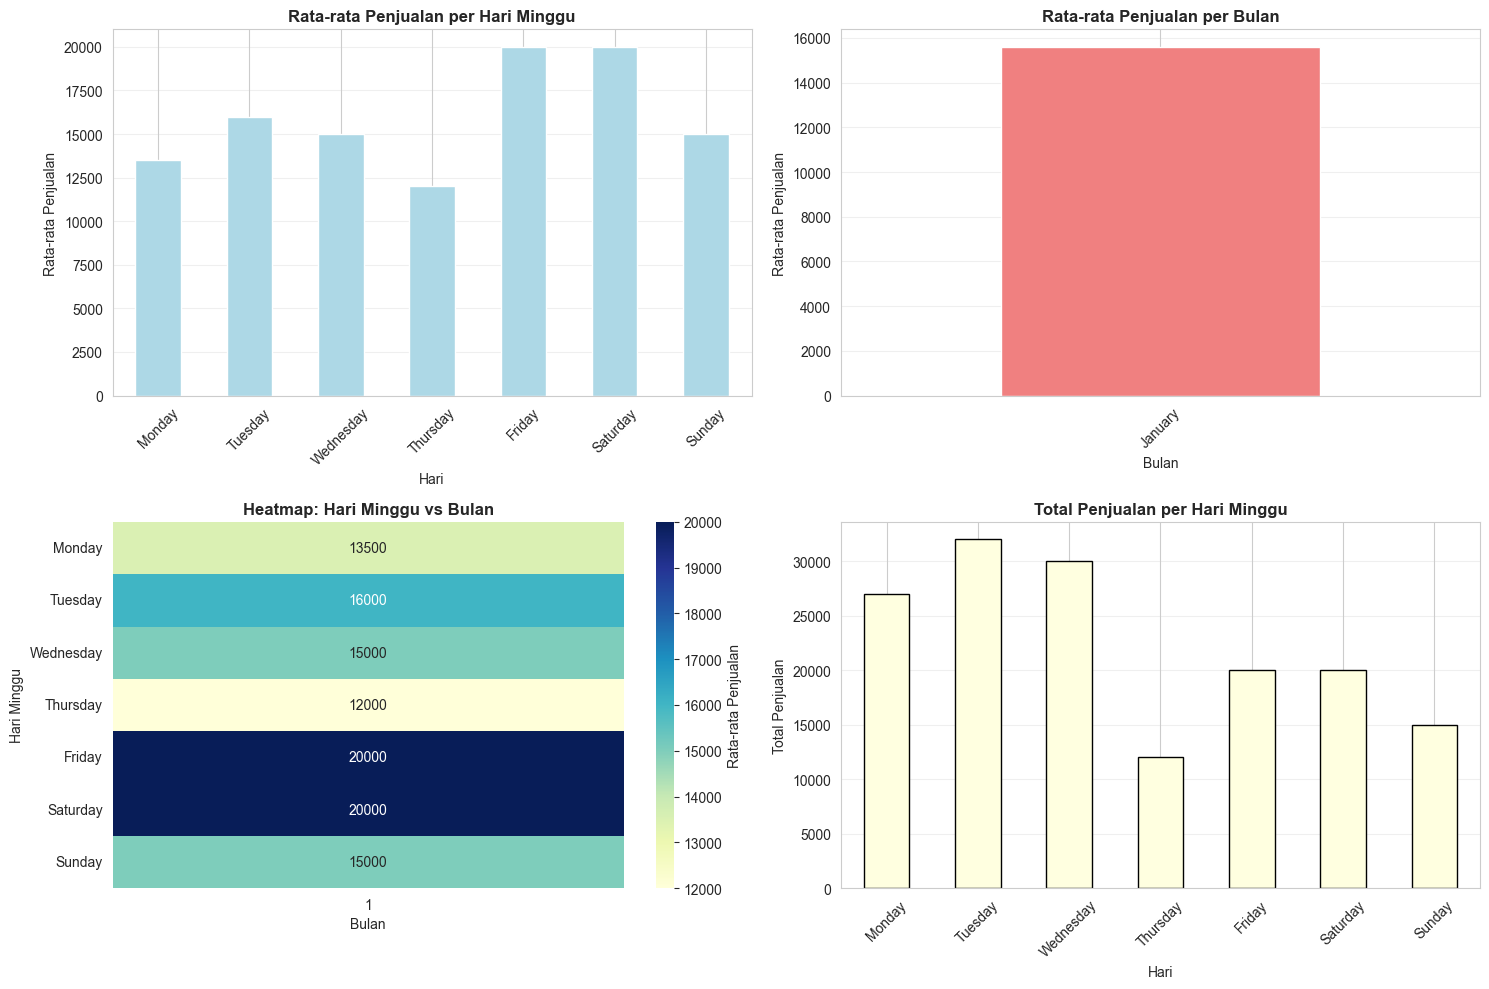


📊 INSIGHT POLA WAKTU - HARI MINGGU:
  • Monday: 13500.00 unit/hari
  • Tuesday: 16000.00 unit/hari
  • Wednesday: 15000.00 unit/hari
  • Thursday: 12000.00 unit/hari
  • Friday: 20000.00 unit/hari
  • Saturday: 20000.00 unit/hari
  • Sunday: 15000.00 unit/hari

💡 Hari paling ramai: Friday (20000.00 unit/hari)
   Hari paling sepi: Thursday (12000.00 unit/hari)

📊 INSIGHT POLA WAKTU - BULAN:
  • Bulan paling ramai: January (15600.00 unit/hari)
  • Bulan paling sepi: January (15600.00 unit/hari)


In [12]:
print("=" * 80)
print("📅 ANALISIS POLA WAKTU (HARI DAN BULAN)")
print("=" * 80)

if date_col:
    # Ekstrak hari dalam minggu dan bulan
    df['day_of_week'] = df[date_col].dt.day_name()
    df['month'] = df[date_col].dt.month
    df['month_name'] = df[date_col].dt.strftime('%B')
    
    # Urutan hari minggu
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_order_id = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
    
    # Rata-rata penjualan per hari minggu
    daily_pattern = df.groupby('day_of_week')[target_col].mean()
    daily_pattern = daily_pattern.reindex([d for d in day_order if d in daily_pattern.index])
    
    # Rata-rata penjualan per bulan
    monthly_pattern = df.groupby('month_name')[target_col].mean()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Bar chart per hari minggu
    daily_pattern.plot(kind='bar', ax=axes[0, 0], color='lightblue')
    axes[0, 0].set_title('Rata-rata Penjualan per Hari Minggu', fontweight='bold')
    axes[0, 0].set_ylabel('Rata-rata Penjualan')
    axes[0, 0].set_xlabel('Hari')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Bar chart per bulan
    monthly_pattern.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
    axes[0, 1].set_title('Rata-rata Penjualan per Bulan', fontweight='bold')
    axes[0, 1].set_ylabel('Rata-rata Penjualan')
    axes[0, 1].set_xlabel('Bulan')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Heatmap hari vs bulan
    heatmap_data = df.pivot_table(values=target_col, index='day_of_week', columns='month', aggfunc='mean')
    heatmap_data = heatmap_data.reindex([d for d in day_order if d in heatmap_data.index])
    
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[1, 0], cbar_kws={'label': 'Rata-rata Penjualan'})
    axes[1, 0].set_title('Heatmap: Hari Minggu vs Bulan', fontweight='bold')
    axes[1, 0].set_ylabel('Hari Minggu')
    axes[1, 0].set_xlabel('Bulan')
    
    # Penjualan total per hari minggu
    daily_total = df.groupby('day_of_week')[target_col].sum()
    daily_total = daily_total.reindex([d for d in day_order if d in daily_total.index])
    daily_total.plot(kind='bar', ax=axes[1, 1], color='lightyellow', edgecolor='black')
    axes[1, 1].set_title('Total Penjualan per Hari Minggu', fontweight='bold')
    axes[1, 1].set_ylabel('Total Penjualan')
    axes[1, 1].set_xlabel('Hari')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 INSIGHT POLA WAKTU - HARI MINGGU:")
    for day, avg_sales in daily_pattern.items():
        print(f"  • {day}: {avg_sales:.2f} unit/hari")
    
    best_day = daily_pattern.idxmax()
    worst_day = daily_pattern.idxmin()
    print(f"\n💡 Hari paling ramai: {best_day} ({daily_pattern[best_day]:.2f} unit/hari)")
    print(f"   Hari paling sepi: {worst_day} ({daily_pattern[worst_day]:.2f} unit/hari)")
    
    print(f"\n📊 INSIGHT POLA WAKTU - BULAN:")
    best_month = monthly_pattern.idxmax()
    worst_month = monthly_pattern.idxmin()
    print(f"  • Bulan paling ramai: {best_month} ({monthly_pattern[best_month]:.2f} unit/hari)")
    print(f"  • Bulan paling sepi: {worst_month} ({monthly_pattern[worst_month]:.2f} unit/hari)")
else:
    print("⚠️  Kolom tanggal tidak ditemukan. Analisis pola waktu dilewati.")

## 11. Korelasi Antar Fitur

📊 ANALISIS KORELASI ANTAR FITUR


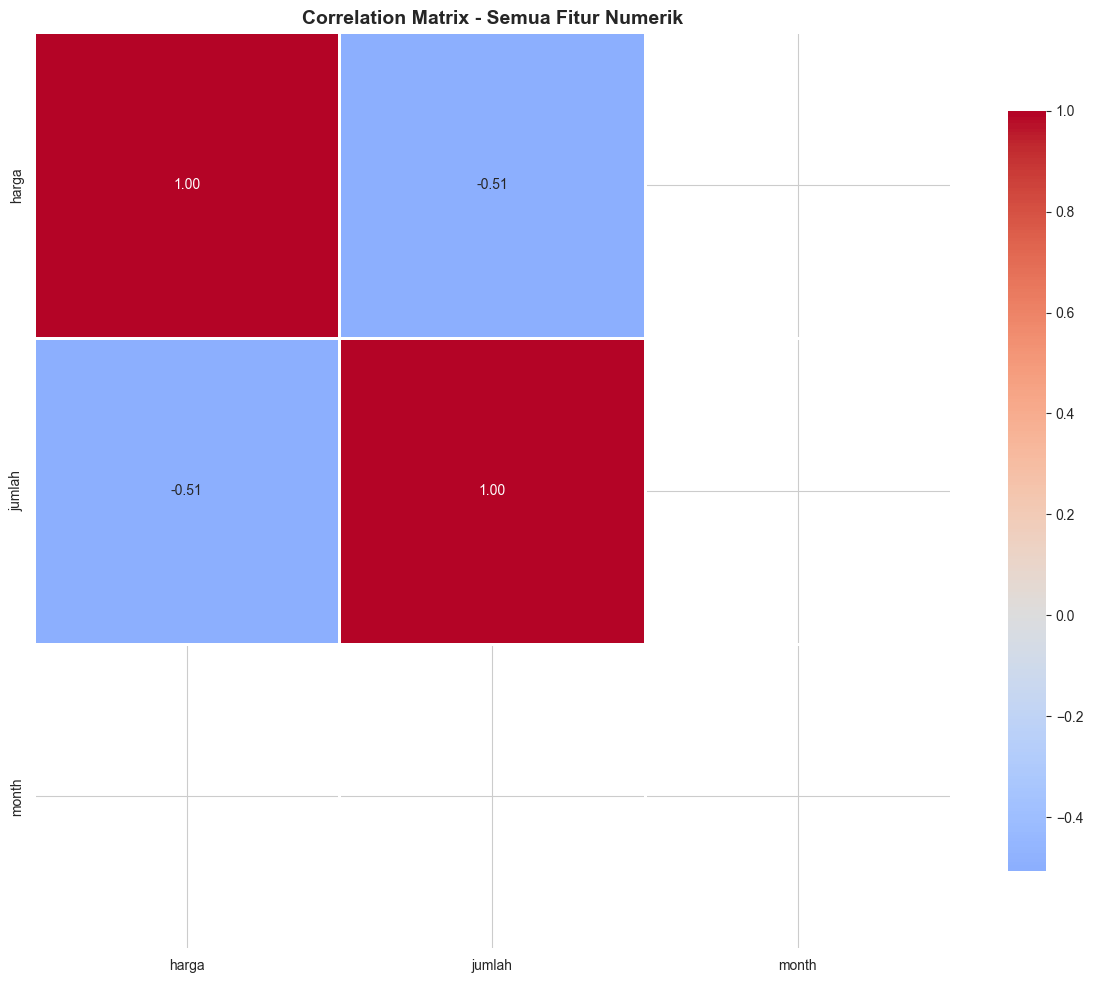


📈 KORELASI DENGAN TARGET (harga):
harga     1.000000
jumlah   -0.506406
month          NaN
Name: harga, dtype: float64

🔥 KORELASI KUAT (> 0.7 atau < -0.7):
  ℹ️  Tidak ada korelasi sangat kuat dengan target

💡 FITUR PALING BERKORELASI:
  1. jumlah: -0.506
  2. month: nan


In [13]:
print("=" * 80)
print("📊 ANALISIS KORELASI ANTAR FITUR")
print("=" * 80)

# Hitung correlation matrix (hanya kolom numerik)
numeric_data = df.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Semua Fitur Numerik', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Highlight korelasi kuat dengan target
if target_col in corr_matrix.columns:
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    
    print(f"\n📈 KORELASI DENGAN TARGET ({target_col}):")
    print(target_corr)
    
    print(f"\n🔥 KORELASI KUAT (> 0.7 atau < -0.7):")
    strong_corr = target_corr[(target_corr.abs() > 0.7) & (target_corr.index != target_col)]
    if len(strong_corr) > 0:
        for fitur, corr_val in strong_corr.items():
            direction = "positif" if corr_val > 0 else "negatif"
            print(f"  • {fitur}: {corr_val:.3f} ({direction})")
    else:
        print("  ℹ️  Tidak ada korelasi sangat kuat dengan target")
    
    print(f"\n💡 FITUR PALING BERKORELASI:")
    top_corr = target_corr.drop(target_col).abs().nlargest(3)
    for idx, (fitur, corr_val) in enumerate(top_corr.items(), 1):
        actual_corr = target_corr[fitur]
        print(f"  {idx}. {fitur}: {actual_corr:.3f}")
else:
    print("⚠️  Target variable tidak ditemukan dalam fitur numerik")

## 12. Hubungan Fitur vs Target

🔗 HUBUNGAN FITUR vs TARGET VARIABLE


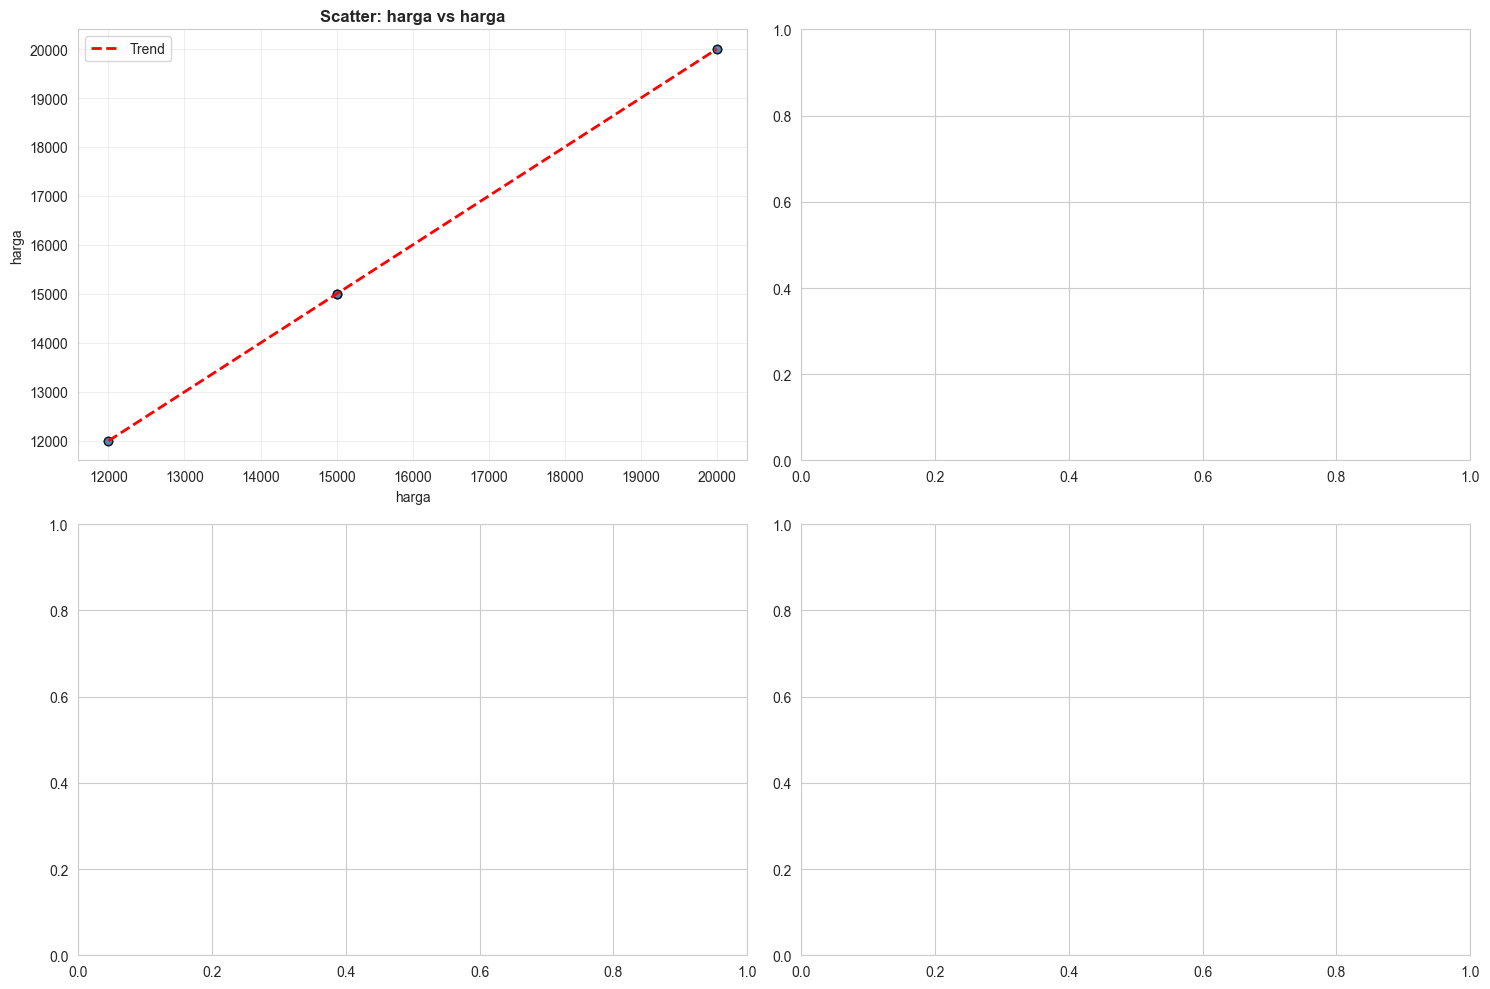


💡 INSIGHT HUBUNGAN FITUR:
  • harga vs harga: Korelasi 1.000
    → Ada korelasi kuat positif (semakin mahal, semakin banyak terjual)


In [14]:
print("=" * 80)
print("🔗 HUBUNGAN FITUR vs TARGET VARIABLE")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot: harga vs jumlah_terjual (dengan regression line)
price_col = None
for col in df.columns:
    if 'harga' in col.lower() or 'price' in col.lower():
        price_col = col
        break

if price_col and price_col in numeric_cols:
    axes[0, 0].scatter(df[price_col], df[target_col], alpha=0.6, color='steelblue', edgecolor='black')
    
    # Regression line
    z = np.polyfit(df[price_col].dropna(), df[target_col].dropna(), 1)
    p = np.poly1d(z)
    axes[0, 0].plot(df[price_col].sort_values(), p(df[price_col].sort_values()), "r--", linewidth=2, label='Trend')
    
    axes[0, 0].set_title(f'Scatter: {price_col} vs {target_col}', fontweight='bold')
    axes[0, 0].set_xlabel(price_col)
    axes[0, 0].set_ylabel(target_col)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

# 2. Violin plot: target per kategori
if category_col:
    df_plot = df[[category_col, target_col]].dropna()
    sns.violinplot(data=df_plot, x=category_col, y=target_col, ax=axes[0, 1], palette='Set2')
    axes[0, 1].set_title(f'Distribusi {target_col} per {category_col}', fontweight='bold')
    axes[0, 1].set_xlabel(category_col)
    axes[0, 1].set_ylabel(target_col)
    axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Box plot: target per kategori (alternatif)
if category_col:
    sns.boxplot(data=df, x=category_col, y=target_col, ax=axes[1, 0], palette='pastel')
    axes[1, 0].set_title(f'Box Plot: {target_col} per {category_col}', fontweight='bold')
    axes[1, 0].set_xlabel(category_col)
    axes[1, 0].set_ylabel(target_col)
    axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Metode pembayaran
payment_col = None
for col in df.columns:
    if 'pembayaran' in col.lower() or 'payment' in col.lower():
        payment_col = col
        break

if payment_col:
    sns.boxplot(data=df, x=payment_col, y=target_col, ax=axes[1, 1], palette='Set1')
    axes[1, 1].set_title(f'Box Plot: {target_col} per {payment_col}', fontweight='bold')
    axes[1, 1].set_xlabel(payment_col)
    axes[1, 1].set_ylabel(target_col)
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n💡 INSIGHT HUBUNGAN FITUR:")
if price_col and price_col in numeric_cols:
    corr_price_target = df[price_col].corr(df[target_col])
    print(f"  • {price_col} vs {target_col}: Korelasi {corr_price_target:.3f}")
    if abs(corr_price_target) > 0.5:
        direction = "positif (semakin mahal, semakin banyak terjual)" if corr_price_target > 0 else "negatif (semakin mahal, semakin sedikit terjual)"
        print(f"    → Ada korelasi kuat {direction}")

if category_col:
    print(f"  • Kategori mempengaruhi distribusi {target_col}")
    category_mean = df.groupby(category_col)[target_col].mean().sort_values(ascending=False)
    print(f"    → Kategori dengan rata-rata tertinggi: {category_mean.index[0]} ({category_mean.iloc[0]:.2f})")

if payment_col:
    print(f"  • Metode pembayaran mempengaruhi pola pembelian")
    payment_mean = df.groupby(payment_col)[target_col].mean().sort_values(ascending=False)
    print(f"    → Metode dengan rata-rata tertinggi: {payment_mean.index[0]} ({payment_mean.iloc[0]:.2f})")

## 13. Ringkasan & Kesimpulan EDA

### 📊 Kondisi Data
- **Dimensi Dataset**: [Sesuaikan dengan hasil analisis]
- **Missing Values**: [Sesuaikan dengan rekomendasi penanganan]
- **Duplikat**: [Sesuaikan dengan status duplikat]
- **Outlier**: [Sesuaikan dengan metode IQR detection]

### 📈 Tren Penjualan Utama
- **Periode Tertinggi**: [Tanggal/bulan dengan penjualan tertinggi]
- **Periode Terendah**: [Tanggal/bulan dengan penjualan terendah]
- **Rata-rata Harian**: [Nilai rata-rata penjualan per hari]
- **Volatilitas**: [Tinggi/Sedang/Rendah berdasarkan standar deviasi]

### 🏆 Produk & Kategori Unggulan
- **Top Produk**: [3-5 produk dengan penjualan tertinggi]
- **Kategori Dominan**: [Kategori dengan proporsi penjualan terbesar]
- **Diversifikasi**: [Jumlah produk unik per kategori]

### 🕐 Pola Waktu Penjualan
- **Hari Terramai**: [Hari minggu dengan penjualan tertinggi]
- **Hari Tersepi**: [Hari minggu dengan penjualan terendah]
- **Bulan Tersibuk**: [Bulan dengan penjualan tertinggi]
- **Variasi Mingguan**: [Pola mingguan yang konsisten/fluktuatif]

### 🔗 Korelasi & Hubungan Fitur
- **Fitur Paling Berpengaruh**: [Top 3 fitur dengan korelasi tertinggi ke target]
- **Hubungan Harga-Kuantitas**: [Positif/Negatif]
- **Pengaruh Kategori**: [Signifikan/Tidak signifikan]
- **Pengaruh Metode Pembayaran**: [Signifikan/Tidak signifikan]

### 📋 Rekomendasi Preprocessing
1. **Missing Values**: 
   - Drop kolom dengan missing > 50%
   - Impute kolom dengan missing < 20% menggunakan mean/median/mode
   - Drop baris dengan missing di kolom kritis

2. **Outlier**:
   - Gunakan capping (IQR method) untuk outlier ekstrim
   - Atau remove baris dengan outlier di multiple kolom

3. **Duplikat**:
   - Drop duplicate rows dengan `df.drop_duplicates()`

4. **Feature Engineering**:
   - Ekstrak fitur waktu: hari, bulan, kuartal, day-of-week
   - Buat lag features untuk time series pattern
   - Encoding kategorikal (Label Encoding atau One-Hot)
   - Scaling numerik (StandardScaler atau MinMaxScaler)

5. **Data Splitting**:
   - Split 70% train, 20% validation, 10% test
   - Atau gunakan time-series split jika ada temporal dependence

### ✅ Selanjutnya:
1. Lakukan preprocessing sesuai rekomendasi di atas
2. Buat file processed data di `data/processed/`
3. Implementasi fungsi-fungsi di `utils/preprocessing.py`
4. Lanjut ke tahap feature engineering & modeling